# 08. 表現学習とオートエンコーダ — 圧縮が意味を作る

## この章で分かること

- **表現学習**: データを「意味のある少数の数」に圧縮する
- **オートエンコーダ (AE)**: ボトルネックを通して自分自身を再構成する
- **デノイジング AE**: ノイズ除去を通じて頑健な表現を学ぶ
- **変分オートエンコーダ (VAE)**: 滑らかでサンプリング可能な潜在空間
- 潜在空間の可視化・補間・クラスタ構造

01 章で「隠れ層がデータをほぐす」のを見ました。
本章はそれを目的そのものにします — **良い表現を学ぶこと自体** がゴールです。

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from nn_textbook import datasets, plotting
from nn_textbook.training import get_device, set_seed

set_seed(0)
# Committed outputs use the CPU; set NN_TEXTBOOK_GPU=1 to run on the GPU.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
pio.renderers.default = "plotly_mimetype+notebook_connected"
np.set_printoptions(precision=3, suppress=True)
print("device:", device)

device: cpu


## 1. Intuition — ボトルネックが本質を絞り出す

オートエンコーダは「入力を一度小さな空間に潰し、そこから元に戻す」ネットです。

$$
x \xrightarrow{\text{encoder}} z \xrightarrow{\text{decoder}} \hat{x}, \qquad
\min \|x - \hat{x}\|^2
$$

- **エンコーダ**: $x$ を低次元の **潜在ベクトル** $z$ に圧縮
- **デコーダ**: $z$ から $x$ を再構成
- $z$ の次元(ボトルネック)が小さいほど、本質的な情報だけを残さざるを得ない

「うまく再構成するには、データの構造を $z$ に詰め込むしかない」 — これが表現学習の駆動力です。
MNIST を使います。

In [2]:
# Prepare MNIST as flat vectors for the autoencoders.
def mnist_flat(n_train=8000, n_val=2000, batch=128):
    tr = datasets.load_mnist(train=True, n=n_train, seed=0)
    va = datasets.load_mnist(train=False, n=n_val, seed=0)
    Xtr = torch.stack([im for im, _ in tr]).reshape(n_train, -1)
    ytr = torch.tensor([y for _, y in tr])
    Xva = torch.stack([im for im, _ in va]).reshape(n_val, -1)
    yva = torch.tensor([y for _, y in va])
    return Xtr, ytr, Xva, yva


Xtr, ytr, Xva, yva = mnist_flat()
print("flattened image shape:", Xtr.shape, "(each row is a 28x28 = 784 vector)")

flattened image shape: torch.Size([8000, 784]) (each row is a 28x28 = 784 vector)


## 2. Computation — オートエンコーダを学習する

`nn_textbook.models.make_autoencoder` は対称な MLP で、潜在次元は 2(可視化のため)。
再構成損失(MSE)で学習します。

In [3]:
# Train an autoencoder with a 2-D bottleneck (so we can plot the latent space).
from nn_textbook.models import make_autoencoder

set_seed(0)
ae = make_autoencoder(latent_dim=2, input_dim=784).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(Xtr), batch_size=128, shuffle=True)

losses = []
for epoch in range(20):
    for (xb,) in loader:
        xb = xb.to(device)
        recon, _ = ae(xb)
        loss = F.mse_loss(recon, xb)
        opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
print(f"final reconstruction loss: {losses[-1]:.4f}")

final reconstruction loss: 0.0454


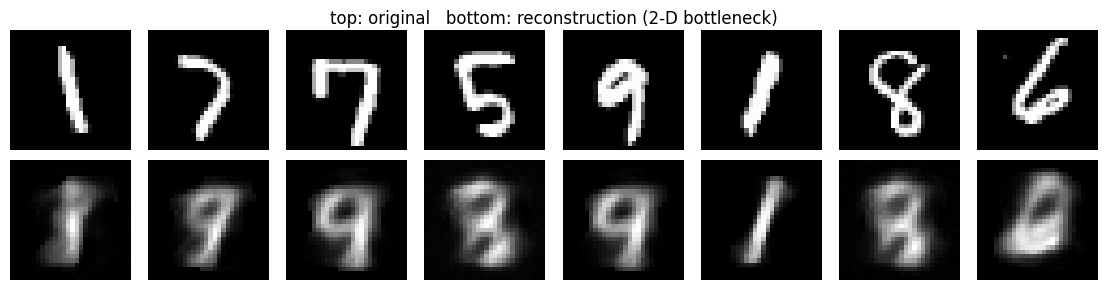

In [4]:
# Reconstruction quality: original vs reconstructed digits.
ae.eval()
with torch.no_grad():
    recon, _ = ae(Xva[:8].to(device))
recon = recon.cpu()
imgs = [Xva[i].reshape(28, 28) for i in range(8)] + [recon[i].reshape(28, 28) for i in range(8)]
plotting.plot_image_grid(imgs, ncols=8)
plt.suptitle("top: original   bottom: reconstruction (2-D bottleneck)", y=1.02)
plt.show()

2 次元という極端なボトルネックでも、桁の大まかな形が再構成できています。

## 3. Visualization — 潜在空間

学習した 2 次元潜在空間に検証データを射影し、桁ラベルで色付けします。
似た桁が近くに集まっていれば、AE が **意味のある表現** を学んだ証拠です。

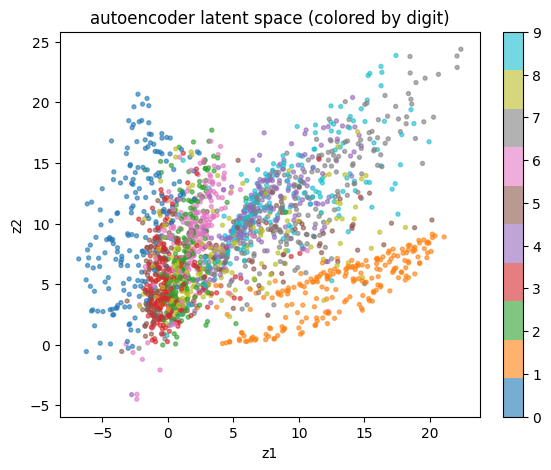

In [5]:
# Project the validation set into the 2-D latent space, colored by digit.
ae.eval()
with torch.no_grad():
    _, Z = ae(Xva.to(device))
Z = Z.cpu().numpy()
plotting.plot_latent_space(Z, yva.numpy(), title="autoencoder latent space (colored by digit)")
plt.show()

## 4. デノイジングオートエンコーダ

**デノイジング AE (DAE)** は、ノイズを加えた入力から **きれいな** 元画像を復元するよう学習します。

$$
\tilde{x} = x + \text{noise}, \qquad \min \|x - \text{decoder}(\text{encoder}(\tilde{x}))\|^2
$$

「ノイズを無視して本質を捉える」ことを強制するので、より頑健な表現になります。
ノイズ除去そのものが応用でもあります。

final denoising loss: 0.0341


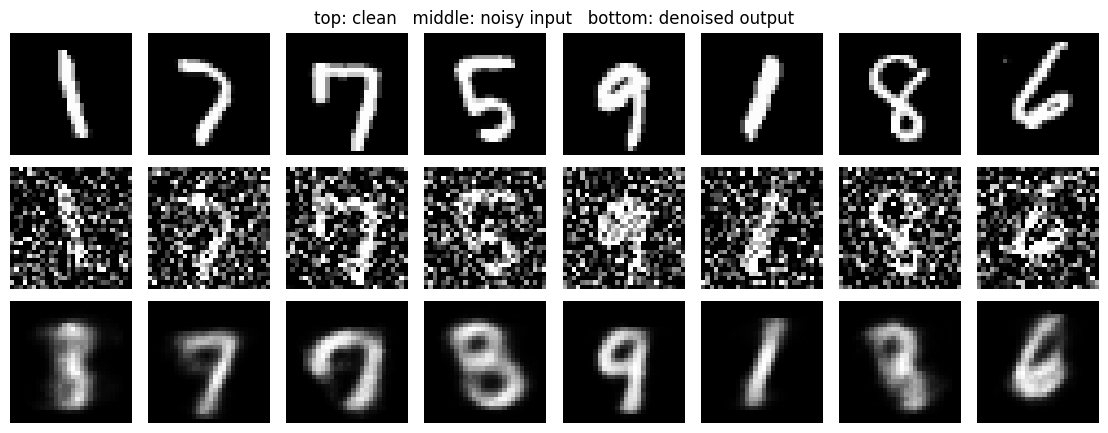

In [6]:
# Denoising autoencoder: learn to map noisy digits back to clean ones.
set_seed(0)
dae = make_autoencoder(latent_dim=16, input_dim=784).to(device)   # bigger latent
opt = torch.optim.Adam(dae.parameters(), lr=1e-3)
noise_std = 0.5

for epoch in range(20):
    for (xb,) in loader:
        xb = xb.to(device)
        noisy = (xb + noise_std * torch.randn_like(xb)).clamp(0, 1)
        recon, _ = dae(noisy)
        loss = F.mse_loss(recon, xb)        # target is the CLEAN image
        opt.zero_grad(); loss.backward(); opt.step()
print(f"final denoising loss: {loss.item():.4f}")

dae.eval()
with torch.no_grad():
    noisy = (Xva[:8] + noise_std * torch.randn_like(Xva[:8])).clamp(0, 1)
    denoised, _ = dae(noisy.to(device))
denoised = denoised.cpu()
imgs = ([Xva[i].reshape(28, 28) for i in range(8)]
        + [noisy[i].reshape(28, 28) for i in range(8)]
        + [denoised[i].reshape(28, 28) for i in range(8)])
plotting.plot_image_grid(imgs, ncols=8)
plt.suptitle("top: clean   middle: noisy input   bottom: denoised output", y=1.02)
plt.show()

## 5. Definition — 変分オートエンコーダ (VAE)

通常の AE の潜在空間には穴があり、ランダムな $z$ をデコードしても意味のある画像になりません。
**VAE** は潜在を **確率分布** にして、空間を滑らかで連続にします。

- エンコーダは各入力に対し、潜在の **平均 $\mu$ と分散 $\sigma^2$** を出す
- $z = \mu + \sigma \odot \epsilon$($\epsilon \sim \mathcal{N}(0, I)$)とサンプリング(**reparameterization trick**)
- 損失は **再構成 + KL 正則化**:

$$
L = \underbrace{\|x - \hat{x}\|^2}_{\text{reconstruction}} + \beta \underbrace{D_{\mathrm{KL}}(\mathcal{N}(\mu, \sigma^2)\,\|\,\mathcal{N}(0, I))}_{\text{KL to prior}}
$$

第 1 項が再構成誤差、第 2 項が事前分布(標準正規)への KL 正則化です。
KL 項が潜在分布を標準正規 $\mathcal{N}(0, I)$ に寄せるので、
$\mathcal{N}(0,I)$ からサンプリングして新しい画像を **生成** できます。

In [7]:
# Train a VAE; the KL term makes the latent space smooth and samplable.
from nn_textbook.models import make_vae


def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.shape[0]
    # KL( N(mu, sigma^2) || N(0, I) ), closed form.
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.shape[0]
    return recon_loss + beta * kl, recon_loss, kl


set_seed(0)
vae = make_vae(latent_dim=2, input_dim=784).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
for epoch in range(25):
    for (xb,) in loader:
        xb = xb.to(device)
        recon, mu, logvar = vae(xb)
        loss, rl, kl = vae_loss(recon, xb, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
print(f"final: total={loss.item():.2f}  recon={rl.item():.2f}  KL={kl.item():.3f}")

final: total=169.63  recon=164.32  KL=5.310


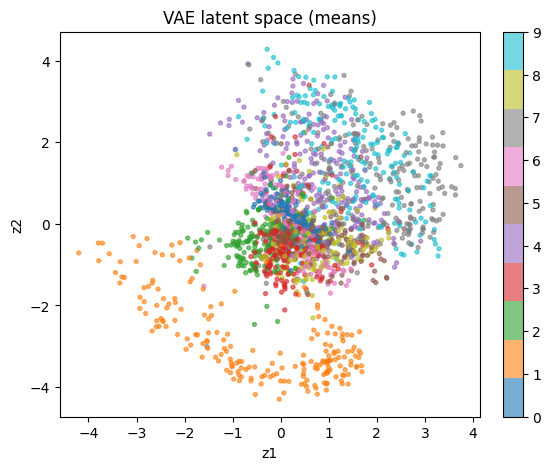

In [8]:
# VAE latent space (means) colored by digit: smoother and more centered than the AE.
vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(Xva.to(device))
plotting.plot_latent_space(mu.cpu().numpy(), yva.numpy(), title="VAE latent space (means)")
plt.show()

## 6. VAE からの生成と潜在補間

KL 正則化のおかげで、潜在空間の **格子点** をデコードすると、
桁が連続的に変化する「地図」が得られます。生成モデルとしての VAE です。

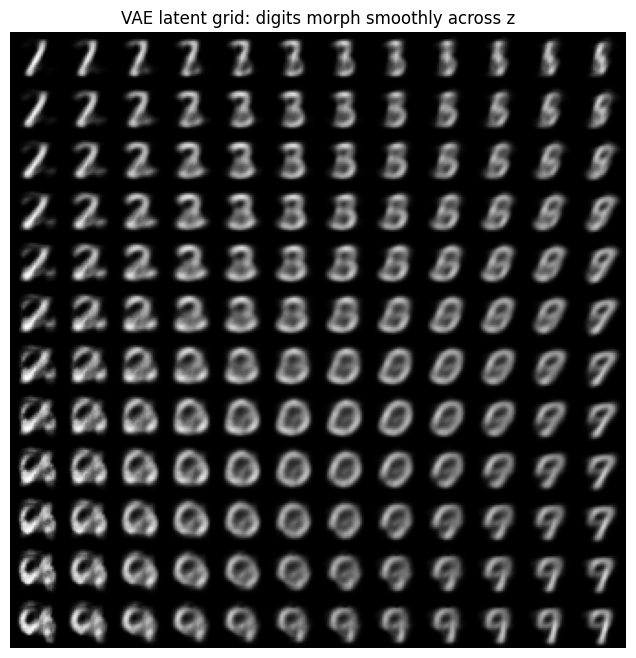

In [9]:
# Decode a grid of latent points: a smooth map over digit space.
import scipy.stats as st

grid_n = 12
# Use the inverse normal CDF so the grid matches the N(0, I) prior density.
coords = st.norm.ppf(np.linspace(0.05, 0.95, grid_n))
canvas = np.zeros((28 * grid_n, 28 * grid_n))
vae.eval()
with torch.no_grad():
    for i, yi in enumerate(coords):
        for j, xj in enumerate(coords):
            z = torch.tensor([[xj, yi]], dtype=torch.float32, device=device)
            img = vae.decoder(z).reshape(28, 28).cpu().numpy()
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(canvas, cmap="gray"); ax.axis("off")
ax.set_title("VAE latent grid: digits morph smoothly across z")
plt.show()

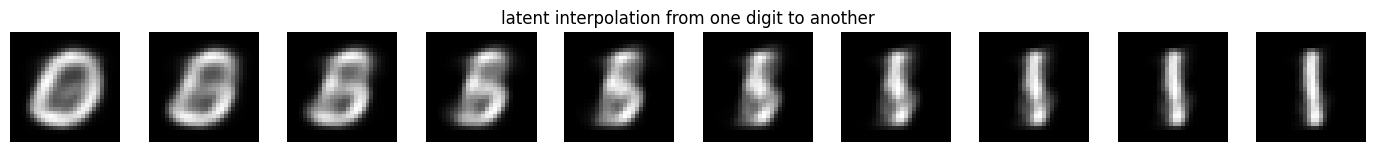

In [10]:
# Latent interpolation between two digits: a smooth morph.
vae.eval()
with torch.no_grad():
    mu_all, _ = vae.encode(Xva.to(device))
mu_all = mu_all.cpu()
# Pick a '0' and a '1' (or any two different digits available).
i0 = (yva == 0).nonzero()[0].item()
i1 = (yva == 1).nonzero()[0].item()
z0, z1 = mu_all[i0], mu_all[i1]
steps = 10
imgs = []
with torch.no_grad():
    for a in np.linspace(0, 1, steps):
        z = ((1 - a) * z0 + a * z1).to(device)
        imgs.append(vae.decoder(z[None]).reshape(28, 28).cpu().numpy())
plotting.plot_image_grid(imgs, ncols=steps)
plt.suptitle("latent interpolation from one digit to another", y=1.05)
plt.show()

### インタラクティブ: 潜在補間(JupyterLab のみ)

2 つの潜在ベクトルの間をスライダーで補間するデモです。静的 HTML では上の連続図を参照。

In [11]:
# Interactive (JupyterLab only): slide alpha to morph between two latent codes.
from nn_textbook.widgets import latent_interpolation_explorer

def decode(z):
    with torch.no_grad():
        zt = torch.tensor(z, dtype=torch.float32, device=device)
        return vae.decoder(zt).cpu().numpy()

latent_interpolation_explorer(decode, z0.numpy(), z1.numpy())

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.05), Output()), _dom_classes…

<function nn_textbook.widgets.latent_interpolation_explorer.<locals>.draw(alpha)>

こちらは **静的 HTML でも動く** Plotly 版の補間スライダーです
(各 $\alpha$ でデコードした画像を事前計算し、フレームとして埋め込んでいます)。

In [12]:
# Plotly version: precomputed frames, slider works in the exported HTML too.
alphas = np.linspace(0, 1, 21)
frames = []
with torch.no_grad():
    for a in alphas:
        z = ((1 - a) * z0 + a * z1).to(device)
        frames.append(vae.decoder(z[None]).reshape(28, 28).cpu().numpy())
fig = plotting.plotly_image_slider(frames, labels=[f"{a:.2f}" for a in alphas],
                                   slider_name="alpha", title="latent interpolation")
fig.show()

## 7. t-SNE による高次元表現の可視化

潜在次元が大きいと直接プロットできません。**t-SNE** は高次元の点を、
近傍関係を保ったまま 2 次元に落とす可視化手法です。
DAE(潜在 16 次元)の表現を t-SNE で見ます。

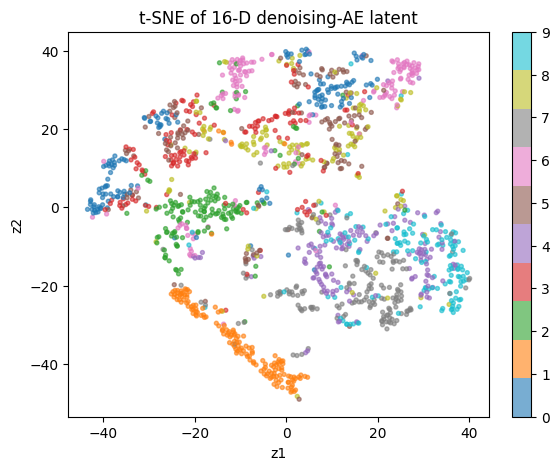

In [13]:
# t-SNE of the 16-D denoising-AE representation reveals digit clusters.
from sklearn.manifold import TSNE

dae.eval()
with torch.no_grad():
    _, Z16 = dae(Xva[:1500].to(device))
Z2 = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(Z16.cpu().numpy())
plotting.plot_latent_space(Z2, yva[:1500].numpy(), title="t-SNE of 16-D denoising-AE latent")
plt.show()

同じ桁が固まり、異なる桁が分かれていれば、教師なしで意味的な表現が学べた証拠です
(ラベルは色付けにのみ使い、学習には使っていません)。

## 8. Failure Mode — 表現学習の落とし穴

- **AE の潜在に穴**: 通常 AE の潜在空間は連続でなく、ランダム $z$ の生成は破綻する(VAE が解決)。
- **posterior collapse**: VAE で KL が強すぎると潜在が無視され、デコーダが平均的な画像だけ出す。
- **ボトルネックが広すぎる**: 圧縮されず恒等写像に近づき、表現が学ばれない。
- **次元削減の歪み**: t-SNE/UMAP の距離・クラスタ間隔は字義どおりには読めない(近傍関係のみ信頼)。

## 9. Application — 表現学習の広がり

- **次元削減・可視化**: 高次元データの探索(AE/VAE/t-SNE/UMAP)
- **異常検知**: 再構成誤差が大きいサンプルを異常とみなす
- **生成**: VAE は画像・分子・音声の生成に使われる(09 章の GAN・拡散と並ぶ系譜)
- **事前学習**: 自己教師あり学習(対照学習・マスク再構成)は現代の表現学習の主流で、
  ラベルなしで強力な表現を作り、下流タスクに転移する

「良い表現を作る」ことは、ラベルが乏しい現実で特に重要です。

## 10. まとめ

- **ボトルネック再構成** がデータの本質だけを潜在に残させる — 表現学習の駆動力。
- **DAE** はノイズ除去課題で頑健な表現を学ぶ(ノイズ除去自体も応用)。
- **VAE** は潜在を分布にし、KL で標準正規へ寄せる — 滑らかな潜在空間と **生成** が手に入る。
- reparameterization trick($z = \mu + \sigma\epsilon$)がサンプリングを微分可能にする。
- 潜在補間・格子デコードで表現の連続性が見える。t-SNE は高次元表現の確認用(距離は字義どおり読まない)。
- 線形 AE ≒ PCA。非線形 AE はその一般化(姉妹教材 `analytics/linear_algebra` の PCA/SVD 章と地続き)。

## 11. Exercises

1. AE のボトルネック次元を 2 / 8 / 32 と変え、再構成品質と潜在の見やすさのトレードオフを調べよ。
2. デノイジング AE の `noise_std` を 0.2 / 0.5 / 1.0 と変え、復元限界を観察せよ。
3. VAE の $\beta$ を 0.1 / 1 / 4 と変え、再構成と潜在の滑らかさ(生成品質)のバランスを見よ。
4. Fashion-MNIST で AE/VAE を学習し、潜在空間がカテゴリでどう分かれるか調べよ。
5. AE の再構成誤差を使って「外れ値の桁」を検出してみよ(異常検知の最小例)。
6. (発展)$\beta$ を非常に大きくして posterior collapse を再現し、生成画像が平均化する様子を見よ。

## 12. Advanced Notes

**reparameterization trick がなぜ必要か。** $z \sim \mathcal{N}(\mu, \sigma^2)$ から直接サンプリングすると、
サンプリング操作を通して勾配が流れません。$z = \mu + \sigma \epsilon$($\epsilon$ は外部ノイズ)と
書き換えると、$\mu, \sigma$ への勾配が定義でき、誤差逆伝播できます。これが VAE 学習の鍵。

**ELBO(変分下界)。** VAE は対数尤度 $\log p(x)$ を直接最大化できないので、
その下界 ELBO $= \mathbb{E}[\log p(x|z)] - D_{\mathrm{KL}}(q(z|x)\|p(z))$ を最大化します。
本章の損失(再構成 $-$ KL、符号反転して最小化)はまさに $-$ELBO です。

**$\beta$-VAE と disentanglement。** KL の重み $\beta$ を上げると、潜在の各次元が
独立した解釈可能な要因(向き・太さなど)に分かれやすくなる($\beta$-VAE)。
再構成品質とのトレードオフがあります。

**AE vs PCA。** 線形 AE(活性化なし)は本質的に PCA と同じ部分空間を学びます。
非線形 AE は曲がった多様体を捉えられる点で PCA を一般化します
(姉妹教材 `analytics/linear_algebra` の 05 章 SVD・PCA と地続きの話です)。

**自己教師あり学習へ。** 現代の表現学習は、AE 的な再構成だけでなく、
対照学習(SimCLR)・マスク予測(MAE, BERT)など「データ自身から作った課題」で
表現を学びます。10 章の LLM 事前学習(次トークン予測)もその一種です。